<a href="https://colab.research.google.com/github/Aditi-codify/ArtiZone-GenAI/blob/main/inflation_forecasting(project_code).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Model Performance ===
Train R²: 1.0000
Test R²: 0.4072
Test MAE: 0.4833
Test RMSE: 0.5757


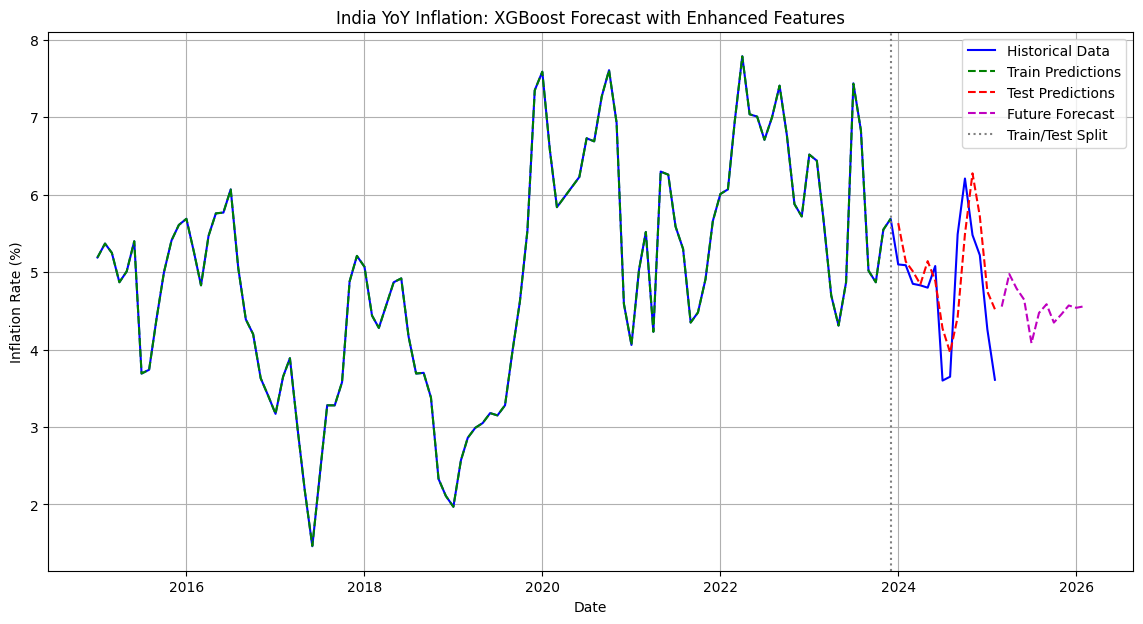

In [ ]:
# XG Boost model------------------------------------------------------------------------>>>>>>>>>>>>>>>>>>>>>>>

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Load and prepare data
data = pd.read_excel('India_YoY_Inflation_2014_2025.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Enhanced Feature Engineering
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['year'] = data.index.year

# Lag features + rolling statistics
for i in range(1, 13):
    data[f'lag_{i}'] = data['YoY_Inflation'].shift(i)
data['rolling_3m_mean'] = data['YoY_Inflation'].rolling(3).mean()
data['rolling_6m_std'] = data['YoY_Inflation'].rolling(6).std()

data.dropna(inplace=True)

# Train-test split (last 12 months for test)
train_end = '2023-12-01'
X = data.drop('YoY_Inflation', axis=1)
y = data['YoY_Inflation']
X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]
X_test = X[X.index > train_end]
y_test = y[y.index > train_end]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = xgb_model.predict(X_train_scaled)
test_preds = xgb_model.predict(X_test_scaled)

# Future Forecast (next 12 months)
future_dates = pd.date_range(start=data.index[-1], periods=13, freq='MS')[1:]
future_data = pd.DataFrame(index=future_dates)
future_data['month'] = future_data.index.month
future_data['quarter'] = future_data.index.quarter
future_data['year'] = future_data.index.year

# Propagate lags for future predictions
last_values = data['YoY_Inflation'].values[-12:]
for i in range(1, 13):
    future_data[f'lag_{i}'] = np.roll(last_values, i-1)[:len(future_dates)]
    future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values

# Calculate rolling stats for future
for date in future_data.index:
    lookback = data.loc[:date].tail(6)
    future_data.loc[date, 'rolling_3m_mean'] = lookback['YoY_Inflation'].tail(3).mean()
    future_data.loc[date, 'rolling_6m_std'] = lookback['YoY_Inflation'].std()

future_X_scaled = scaler.transform(future_data)
future_preds = xgb_model.predict(future_X_scaled)

# Evaluation
print("=== Model Performance ===")
print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['YoY_Inflation'], 'b-', label='Historical Data')
plt.plot(X_train.index, train_preds, 'g--', label='Train Predictions')
plt.plot(X_test.index, test_preds, 'r--', label='Test Predictions')
plt.plot(future_dates, future_preds, 'm--', label='Future Forecast')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title('India YoY Inflation: XGBoost Forecast with Enhanced Features')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)
plt.legend()#
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 106, number of used features: 17
[LightGBM] [Info] Start training from score 4.967075
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1258684631.py:72: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the a

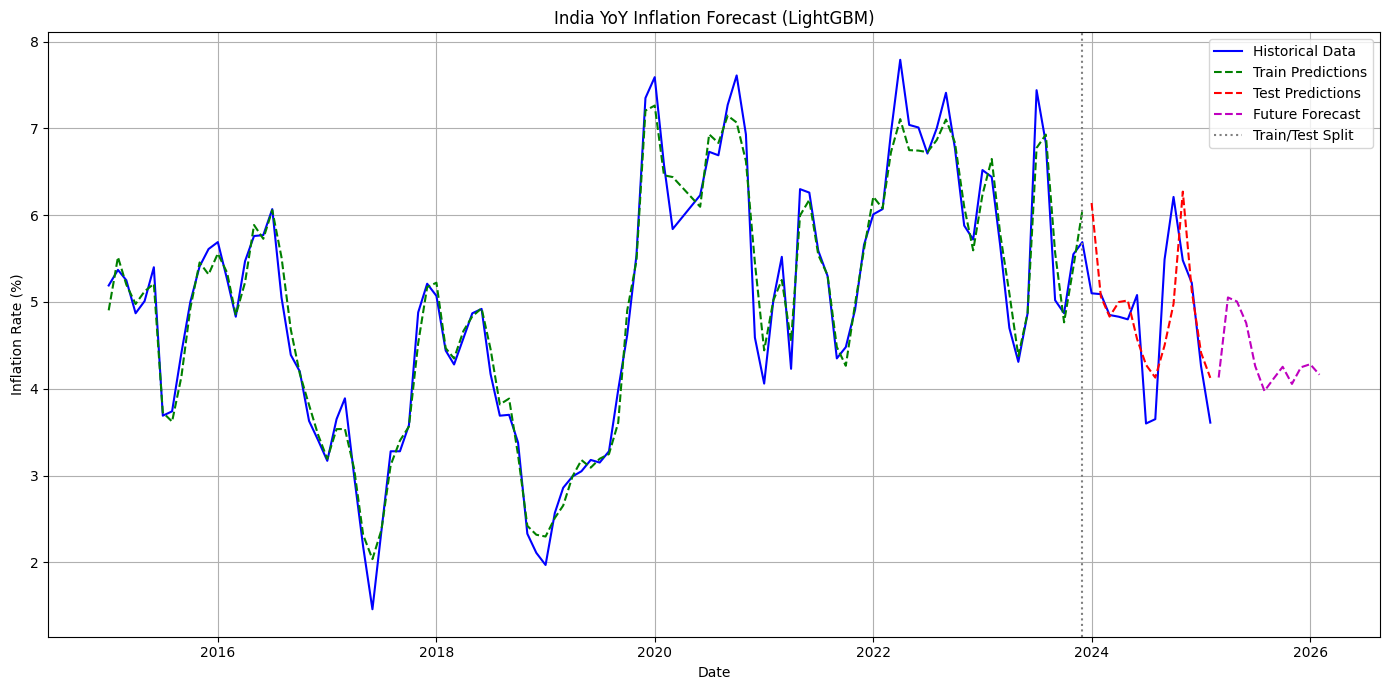

In [ ]:
#Light GBM Regressor---------------------------------------------------------->>>>>>>>>>>>>>>>>>>>>>>>>>>>


# Install required libraries (uncomment if needed)
# !pip install lightgbm scikit-learn pandas matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMRegressor

# Load data
data = pd.read_excel('India_YoY_Inflation_2014_2025.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Feature engineering
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['year'] = data.index.year

# Lag and rolling features
for i in range(1, 13):
    data[f'lag_{i}'] = data['YoY_Inflation'].shift(i)
data['rolling_3m_mean'] = data['YoY_Inflation'].rolling(3).mean()
data['rolling_6m_std'] = data['YoY_Inflation'].rolling(6).std()
data.dropna(inplace=True)

# Train-test split
train_end = '2023-12-01'
X = data.drop('YoY_Inflation', axis=1)
y = data['YoY_Inflation']
X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]
X_test = X[X.index > train_end]
y_test = y[y.index > train_end]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LightGBM Regressor
lgbm_model = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgbm_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = lgbm_model.predict(X_train_scaled)
test_preds = lgbm_model.predict(X_test_scaled)

# Future forecast (next 12 months)
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_data = pd.DataFrame(index=future_dates)
future_data['month'] = future_data.index.month
future_data['quarter'] = future_data.index.quarter
future_data['year'] = future_data.index.year

# Generate lag features using last known values
last_values = data['YoY_Inflation'].values[-12:]
for i in range(1, 13):
    future_data[f'lag_{i}'] = np.roll(last_values, i - 1)[:len(future_data)]
    future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values

# Rolling features (approximate using last available values)
for date in future_data.index:
    lookback = data.loc[:date].tail(6)
    future_data.loc[date, 'rolling_3m_mean'] = lookback['YoY_Inflation'].tail(3).mean()
    future_data.loc[date, 'rolling_6m_std'] = lookback['YoY_Inflation'].std()

# Drop any NA (from early rolling/stat calc)
future_data.dropna(inplace=True)

# Scale future features
future_scaled = scaler.transform(future_data)
future_preds = lgbm_model.predict(future_scaled)

# Evaluation
print("=== LightGBM Model Performance ===")
print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['YoY_Inflation'], 'b-', label='Historical Data')
plt.plot(X_train.index, train_preds, 'g--', label='Train Predictions')
plt.plot(X_test.index, test_preds, 'r--', label='Test Predictions')
plt.plot(future_data.index, future_preds, 'm--', label='Future Forecast')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title('India YoY Inflation Forecast (LightGBM)')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


/tmp/ipython-input-2-60590581.py:71: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values
/tmp/ipython-input-2-60590581.py:71: SettingWithCopyWarning: 
A value is trying to

=== CatBoost Model Performance ===
Train R²: 0.9982
Test R²: 0.0812
Test MAE: 0.6174
Test RMSE: 0.7168


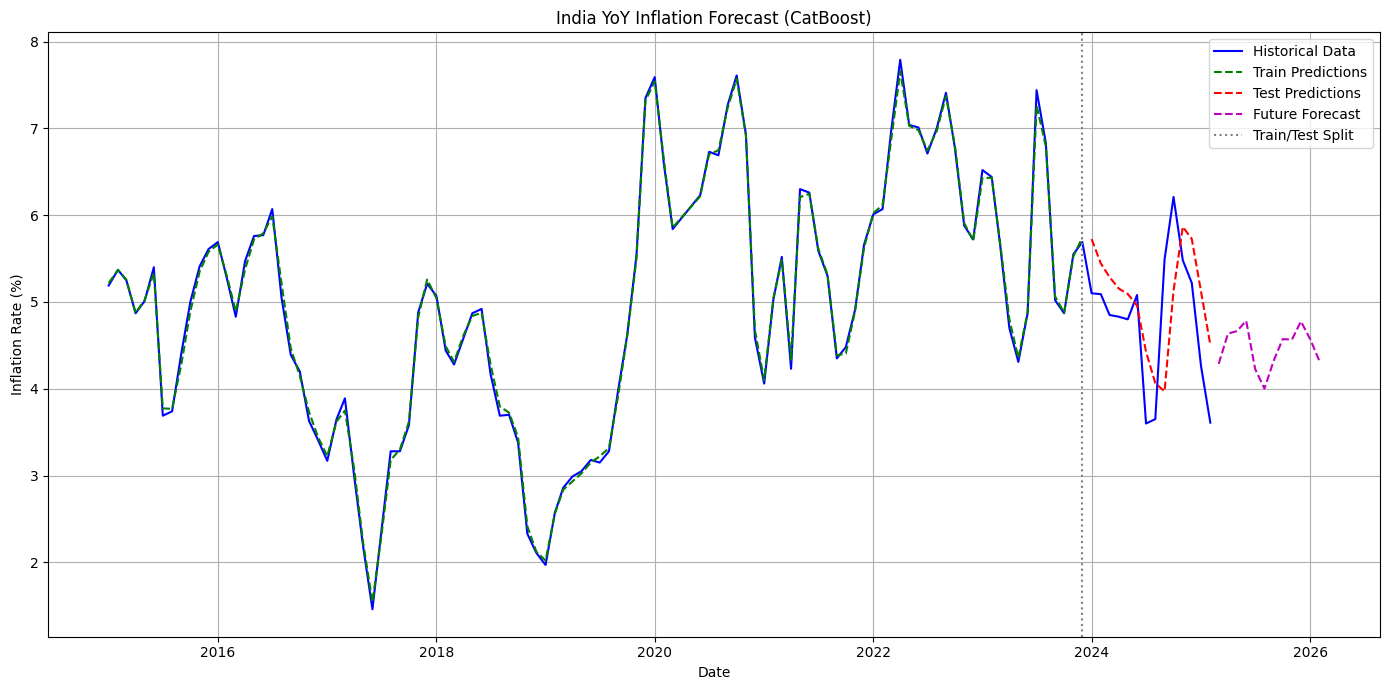

In [ ]:
# cat Boost Regressor

# Install CatBoost if not already installed
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Load and prepare data
data = pd.read_excel('India_YoY_Inflation_2014_2025.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Feature engineering
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['year'] = data.index.year

# Lag and rolling statistics
for i in range(1, 13):
    data[f'lag_{i}'] = data['YoY_Inflation'].shift(i)
data['rolling_3m_mean'] = data['YoY_Inflation'].rolling(3).mean()
data['rolling_6m_std'] = data['YoY_Inflation'].rolling(6).std()
data.dropna(inplace=True)

# Train-test split
train_end = '2023-12-01'
X = data.drop('YoY_Inflation', axis=1)
y = data['YoY_Inflation']
X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]
X_test = X[X.index > train_end]
y_test = y[y.index > train_end]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CatBoost Regressor
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)
cat_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = cat_model.predict(X_train_scaled)
test_preds = cat_model.predict(X_test_scaled)

# Future forecast
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_data = pd.DataFrame(index=future_dates)
future_data['month'] = future_data.index.month
future_data['quarter'] = future_data.index.quarter
future_data['year'] = future_data.index.year

# Lag values for forecast
last_values = data['YoY_Inflation'].values[-12:]
for i in range(1, 13):
    future_data[f'lag_{i}'] = np.roll(last_values, i - 1)[:len(future_data)]
    future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values

# Rolling stats (approximate using historical tail)
for date in future_data.index:
    lookback = data.loc[:date].tail(6)
    future_data.loc[date, 'rolling_3m_mean'] = lookback['YoY_Inflation'].tail(3).mean()
    future_data.loc[date, 'rolling_6m_std'] = lookback['YoY_Inflation'].std()

future_data.dropna(inplace=True)

# Scale future features
future_scaled = scaler.transform(future_data)
future_preds = cat_model.predict(future_scaled)

# Evaluation
print("=== CatBoost Model Performance ===")
print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['YoY_Inflation'], 'b-', label='Historical Data')
plt.plot(X_train.index, train_preds, 'g--', label='Train Predictions')
plt.plot(X_test.index, test_preds, 'r--', label='Test Predictions')
plt.plot(future_data.index, future_preds, 'm--', label='Future Forecast')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title('India YoY Inflation Forecast (CatBoost)')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-10-562269222.py:68: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values
/tmp/ipython-input-10-562269222.py:68: SettingWithCopyWarning: 
A value is tryin

=== Gradient Boosting Regressor Performance ===
Train R²: 1.0000
Test R²: 0.3080
Test MAE: 0.5757
Test RMSE: 0.6221


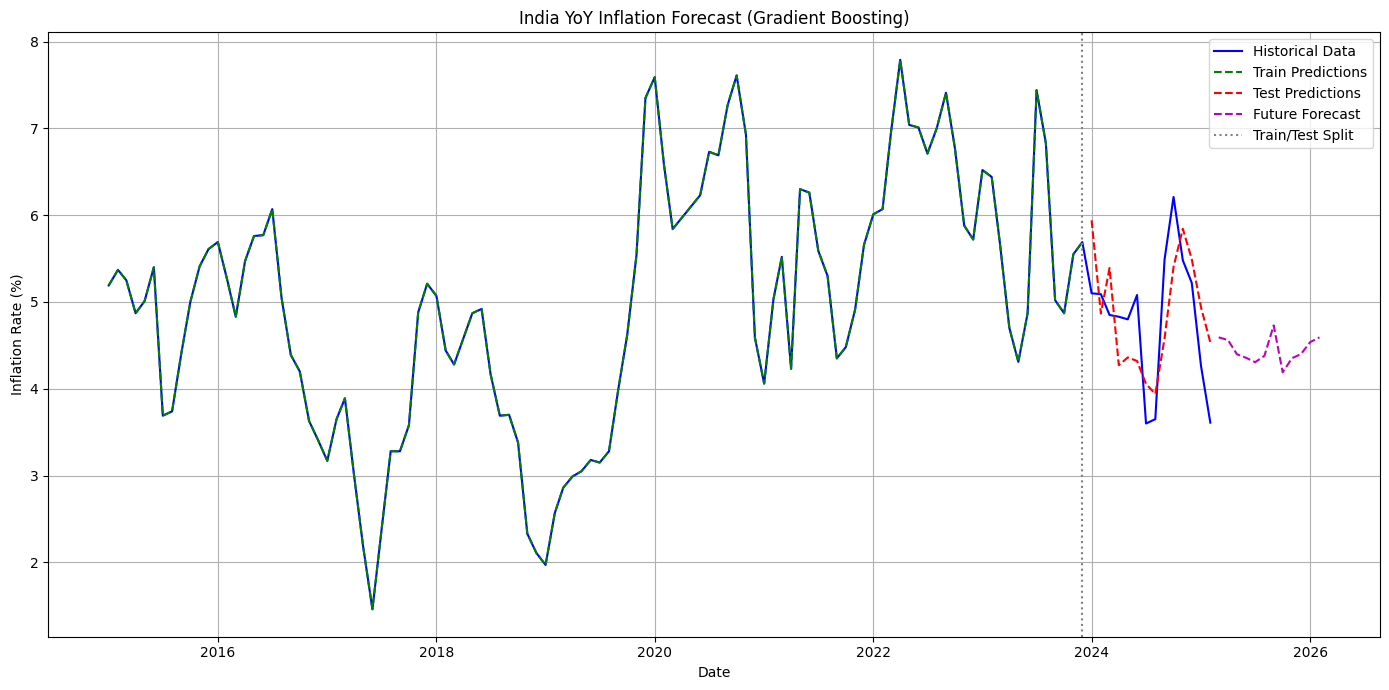

In [ ]:
# Gradient Bosting Regressor



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
data = pd.read_excel('India_YoY_Inflation_2014_2025.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Feature Engineering
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['year'] = data.index.year

# Lag and rolling stats
for i in range(1, 13):
    data[f'lag_{i}'] = data['YoY_Inflation'].shift(i)
data['rolling_3m_mean'] = data['YoY_Inflation'].rolling(3).mean()
data['rolling_6m_std'] = data['YoY_Inflation'].rolling(6).std()
data.dropna(inplace=True)

# Split data
train_end = '2023-12-01'
X = data.drop('YoY_Inflation', axis=1)
y = data['YoY_Inflation']
X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]
X_test = X[X.index > train_end]
y_test = y[y.index > train_end]

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
gbr_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = gbr_model.predict(X_train_scaled)
test_preds = gbr_model.predict(X_test_scaled)

# Future forecasting
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_data = pd.DataFrame(index=future_dates)
future_data['month'] = future_data.index.month
future_data['quarter'] = future_data.index.quarter
future_data['year'] = future_data.index.year

# Lag features
last_values = data['YoY_Inflation'].values[-12:]
for i in range(1, 13):
    future_data[f'lag_{i}'] = np.roll(last_values, i - 1)[:len(future_data)]
    future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values

# Rolling stats
for date in future_data.index:
    lookback = data.loc[:date].tail(6)
    future_data.loc[date, 'rolling_3m_mean'] = lookback['YoY_Inflation'].tail(3).mean()
    future_data.loc[date, 'rolling_6m_std'] = lookback['YoY_Inflation'].std()

future_data.dropna(inplace=True)
future_scaled = scaler.transform(future_data)
future_preds = gbr_model.predict(future_scaled)

# Evaluation
print("=== Gradient Boosting Regressor Performance ===")
print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['YoY_Inflation'], 'b-', label='Historical Data')
plt.plot(X_train.index, train_preds, 'g--', label='Train Predictions')
plt.plot(X_test.index, test_preds, 'r--', label='Test Predictions')
plt.plot(future_data.index, future_preds, 'm--', label='Future Forecast')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title('India YoY Inflation Forecast (Gradient Boosting)')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-11-2005579779.py:66: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values
/tmp/ipython-input-11-2005579779.py:66: SettingWithCopyWarning: 
A value is try

=== Random Forest Regressor Performance ===
Train R²: 0.9781
Test R²: 0.3899
Test MAE: 0.4651
Test RMSE: 0.5841


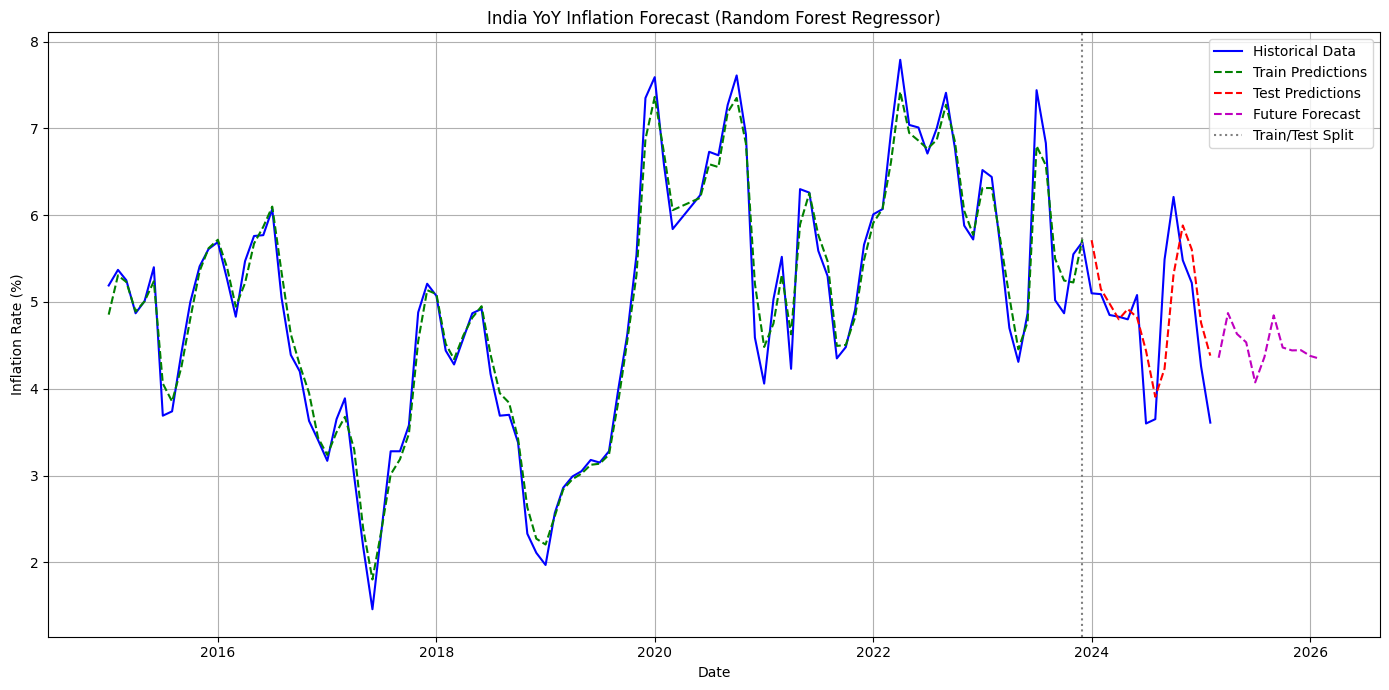

In [ ]:
# Random Forest regression


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
data = pd.read_excel('India_YoY_Inflation_2014_2025.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Feature engineering
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['year'] = data.index.year

# Lag features + rolling stats
for i in range(1, 13):
    data[f'lag_{i}'] = data['YoY_Inflation'].shift(i)
data['rolling_3m_mean'] = data['YoY_Inflation'].rolling(3).mean()
data['rolling_6m_std'] = data['YoY_Inflation'].rolling(6).std()
data.dropna(inplace=True)

# Train/test split (last 12 months for testing)
train_end = '2023-12-01'
X = data.drop('YoY_Inflation', axis=1)
y = data['YoY_Inflation']
X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]
X_test = X[X.index > train_end]
y_test = y[y.index > train_end]

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = rf_model.predict(X_train_scaled)
test_preds = rf_model.predict(X_test_scaled)

# Future forecasting (next 12 months)
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_data = pd.DataFrame(index=future_dates)
future_data['month'] = future_data.index.month
future_data['quarter'] = future_data.index.quarter
future_data['year'] = future_data.index.year

# Lag features for future
last_values = data['YoY_Inflation'].values[-12:]
for i in range(1, 13):
    future_data[f'lag_{i}'] = np.roll(last_values, i - 1)[:len(future_data)]
    future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values

# Rolling stats for future
for date in future_data.index:
    lookback = data.loc[:date].tail(6)
    future_data.loc[date, 'rolling_3m_mean'] = lookback['YoY_Inflation'].tail(3).mean()
    future_data.loc[date, 'rolling_6m_std'] = lookback['YoY_Inflation'].std()

future_data.dropna(inplace=True)
future_scaled = scaler.transform(future_data)
future_preds = rf_model.predict(future_scaled)

# Accuracy metrics
print("=== Random Forest Regressor Performance ===")
print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['YoY_Inflation'], 'b-', label='Historical Data')
plt.plot(X_train.index, train_preds, 'g--', label='Train Predictions')
plt.plot(X_test.index, test_preds, 'r--', label='Test Predictions')
plt.plot(future_data.index, future_preds, 'm--', label='Future Forecast')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title('India YoY Inflation Forecast (Random Forest Regressor)')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-12-2472243211.py:68: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values
/tmp/ipython-input-12-2472243211.py:68: SettingWithCopyWarning: 
A value is try

=== Extra Trees Regressor Performance ===
Train R²: 0.9999
Test R²: 0.3932
Test MAE: 0.4476
Test RMSE: 0.5825


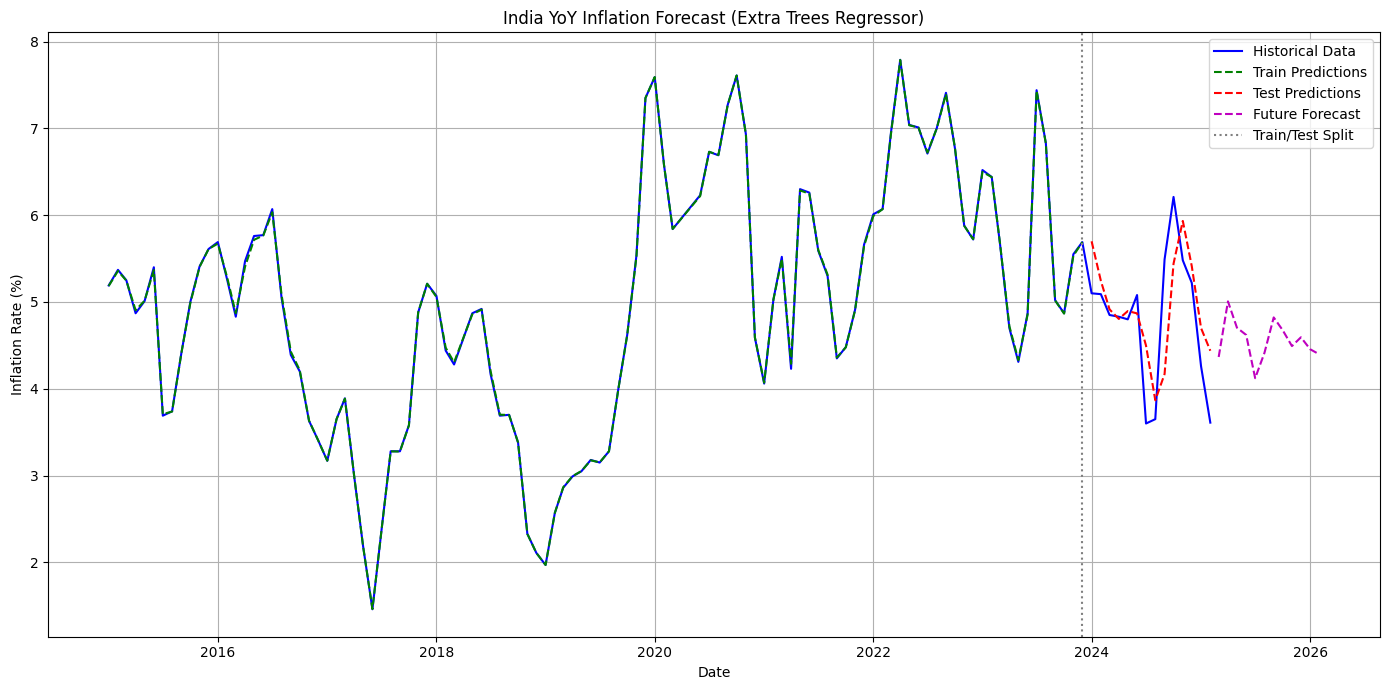

In [ ]:
# Extra Tree Regression




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load and prepare data
data = pd.read_excel('India_YoY_Inflation_2014_2025.xlsx')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Feature engineering
data['month'] = data.index.month
data['quarter'] = data.index.quarter
data['year'] = data.index.year

# Lag features and rolling statistics
for i in range(1, 13):
    data[f'lag_{i}'] = data['YoY_Inflation'].shift(i)
data['rolling_3m_mean'] = data['YoY_Inflation'].rolling(3).mean()
data['rolling_6m_std'] = data['YoY_Inflation'].rolling(6).std()
data.dropna(inplace=True)

# Train-test split
train_end = '2023-12-01'
X = data.drop('YoY_Inflation', axis=1)
y = data['YoY_Inflation']
X_train = X[X.index <= train_end]
y_train = y[y.index <= train_end]
X_test = X[X.index > train_end]
y_test = y[y.index > train_end]

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Extra Trees Regressor
et_model = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
et_model.fit(X_train_scaled, y_train)

# Predictions
train_preds = et_model.predict(X_train_scaled)
test_preds = et_model.predict(X_test_scaled)

# Future forecasting (next 12 months)
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_data = pd.DataFrame(index=future_dates)
future_data['month'] = future_data.index.month
future_data['quarter'] = future_data.index.quarter
future_data['year'] = future_data.index.year

# Lag features for future
last_values = data['YoY_Inflation'].values[-12:]
for i in range(1, 13):
    future_data[f'lag_{i}'] = np.roll(last_values, i - 1)[:len(future_data)]
    future_data[f'lag_{i}'].iloc[:i] = data['YoY_Inflation'].iloc[-(i):].values

# Rolling stats for future
for date in future_data.index:
    lookback = data.loc[:date].tail(6)
    future_data.loc[date, 'rolling_3m_mean'] = lookback['YoY_Inflation'].tail(3).mean()
    future_data.loc[date, 'rolling_6m_std'] = lookback['YoY_Inflation'].std()

future_data.dropna(inplace=True)
future_scaled = scaler.transform(future_data)
future_preds = et_model.predict(future_scaled)

# Evaluation
print("=== Extra Trees Regressor Performance ===")
print(f"Train R²: {r2_score(y_train, train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, test_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['YoY_Inflation'], 'b-', label='Historical Data')
plt.plot(X_train.index, train_preds, 'g--', label='Train Predictions')
plt.plot(X_test.index, test_preds, 'r--', label='Test Predictions')
plt.plot(future_data.index, future_preds, 'm--', label='Future Forecast')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title('India YoY Inflation Forecast (Extra Trees Regressor)')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

=== ARIMA Model Performance ===
Test R²: -1.2572
Test MAE: 0.9191
Test RMSE: 1.1235


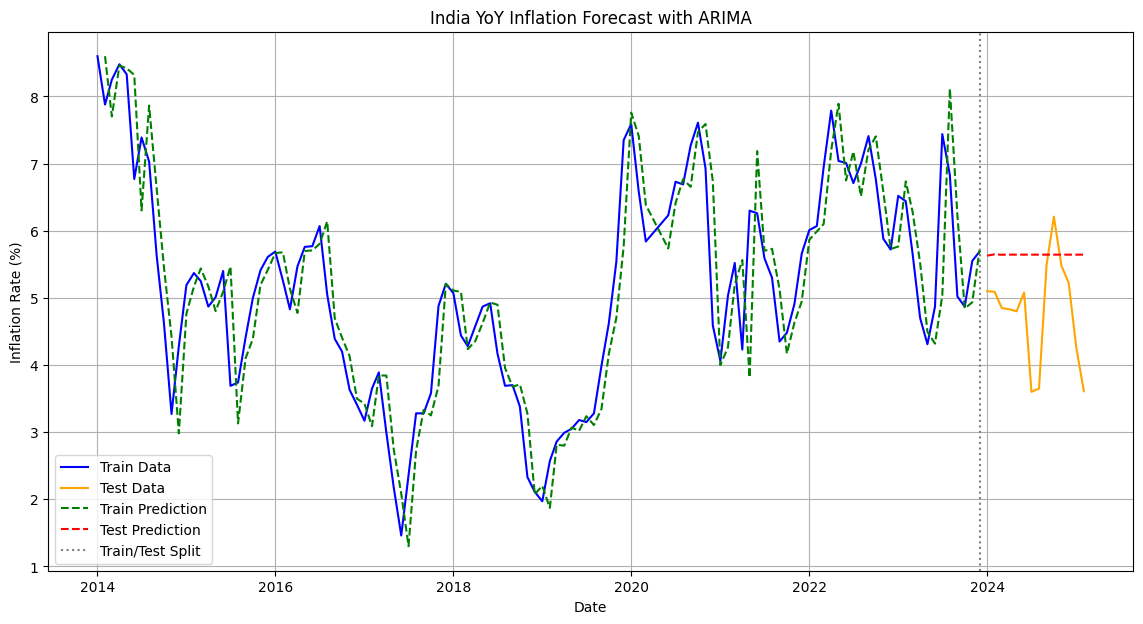

In [ ]:
# ARIMA


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
data = pd.read_excel("India_YoY_Inflation_2014_2025.xlsx")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Target variable
ts = data['YoY_Inflation']

# Split: last 12 months as test
train_end = '2023-12-01'
train = ts[ts.index <= train_end]
test = ts[ts.index > train_end]

# Fit ARIMA model (auto tuned can be done via pmdarima, but here using (1,1,1) as baseline)
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Predict on train
train_pred = model_fit.predict(start=train.index[1], end=train.index[-1], typ='levels')

# Predict on test
test_pred = model_fit.forecast(steps=len(test))

# Evaluate
mae = mean_absolute_error(test, test_pred)
rmse = np.sqrt(mean_squared_error(test, test_pred))
r2 = r2_score(test, test_pred)

# Print results
print("=== ARIMA Model Performance ===")
print(f"Test R²: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Train Data', color='blue')
plt.plot(test.index, test, label='Test Data', color='orange')
plt.plot(train_pred.index, train_pred, '--', label='Train Prediction', color='green')
plt.plot(test.index, test_pred, '--', label='Test Prediction', color='red')
plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Test Split')
plt.title("India YoY Inflation Forecast with ARIMA")
plt.xlabel("Date")
plt.ylabel("Inflation Rate (%)")
plt.grid(True)
plt.legend()
plt.show()
